## 0-Adding libraries

In [ ]:
!pip install git+https://github.com/yaledhlab/vggface.git

  Cloning https://github.com/yaledhlab/vggface.git to /tmp/pip-req-build-aadf3ibv
  Running command git clone --filter=blob:none --quiet https://github.com/yaledhlab/vggface.git /tmp/pip-req-build-aadf3ibv
  Resolved https://github.com/yaledhlab/vggface.git to commit b76539b7588bca69b0030ad7e4f985f877dc7c0a
  Preparing metadata (setup.py) ... done
  Created wheel for keras-vggface: filename=keras_vggface-0.6-py3-none-any.whl size=8332 sha256=0dd48082ff2fa64273c955aa9ddc1f24cb6d86287564b7b9050d4ea1483be09b
  Stored in directory: /tmp/pip-ephem-wheel-cache-wbsc4khb/wheels/79/35/65/07a23ffb182ac2ec3a43776e08b2cf52daf0ce54da686eefbe
Successfully built keras-vggface


In [ ]:
!pip install scipy
!pip install numpy
!pip install Pillow
!pip install matplotlib
!pip install opencv-python
!pip install tensorflow
!pip install Keras
!pip install mtcnn

!pip install keras_applications
!pip install git+https://github.com/yaledhlab/vggface.git

In [ ]:

# for loading/processing the images
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.applications.vgg16 import preprocess_input
from keras.applications.inception_v3 import InceptionV3, preprocess_input
from keras.applications.mobilenet import MobileNet, preprocess_input
from keras.applications.efficientnet import EfficientNetB0, preprocess_input

# models
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input
from keras.models import Model

# clustering and dimension reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import estimate_bandwidth
from sklearn.cluster import MeanShift
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import rand_score, adjusted_rand_score

# for everything else
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from random import randint
import pandas as pd
import pickle


## 1- Load dataset

In [ ]:
!unzip dataset
%cd dataset/
!pwd

In [ ]:
pictures = []

path = !pwd

# creates a ScandirIterator aliased as files
with os.scandir(path[0]) as files:
  # loops through each file in the directory
    for file in files:
      # adds only the image files to the pictures list
        pictures.append(file.name)

pictures.sort()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

num_cols = 5
num_rows = math.ceil(len(pictures) / num_cols)


fig = plt.figure(figsize=(15,100))

for i, img_path in enumerate(pictures):
    img = mpimg.imread(img_path)

    title = os.path.basename(img_path)

    plt.subplot(num_rows, num_cols, i+1)
    plt.title(title)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()


## 2- Feature Extraction

In [ ]:
def extract_features(file, model):
    # load the image as a 224x224 array
    img = load_img(file, target_size=(224,224))
    # convert from 'PIL.Image.Image' to numpy array
    img = np.array(img)
    # reshape the data for the model reshape(num_of_samples, dim 1, dim 2, channels)
    reshaped_img = img.reshape(1,224,224,3)
    # prepare image for model
    imgx = preprocess_input(reshaped_img)
    # get the feature vector
    features = model.predict(imgx)
    return features

### 2-1 Choosing model

#### 2-1-1 Using VGG16

In [ ]:
model = VGG16()
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)

#### 2-1-2 Using ResNet

In [ ]:
model = ResNet50()
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)

102967424/102967424 [==============================] - 1s 0us/step


#### 2-1-3 Using InceptionV3

In [ ]:
model = InceptionV3()
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)

#### 2-1-4 Using MobileNet

In [ ]:
model = MobileNet()
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)

#### 2-1-5 Using EfficientNet

In [ ]:
model = EfficientNetB0()
model = Model(inputs = model.inputs, outputs = model.layers[-2].output)

21834768/21834768 [==============================] - 1s 0us/step


#### 2-1-6 Using FaceNet (TODO)

In [ ]:
from keras.models import load_model
from keras.preprocessing import image
import numpy as np

# Load the pre-trained FaceNet model
model = load_model('facenet_keras.h5')  # Assuming the model is in the same directory

# Define a function to load and preprocess the image
def preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(160, 160))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = img.astype('float32') / 255  # Standardize to [0,1]
    return img

# Define a function to extract features using FaceNet
def extract_features(image_path, model):
    img = preprocess_image(image_path)
    feature_vector = model.predict(img)
    return feature_vector

# Data
X_train = []
y_train = []

for picture in pictures:
    feat = extract_features(picture, model)
    X_train.append(feat)

    label = picture.split('.')[0]
    y_train.append(label)

    data[picture] = feat


#### 2-1-7 Using VggFace (VGG16)

In [ ]:
from matplotlib import pyplot
from PIL import Image
from numpy import asarray
from scipy.spatial.distance import cosine
from mtcnn.mtcnn import MTCNN
# import tensorflow
from keras_vggface.vggface import VGGFace
from keras_vggface import utils

def extract_features(file, model):
    img = load_img(file, target_size=(224,224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = utils.preprocess_input(x, version=1)
    features = model.predict(x)
    return features

model = VGGFace(model='vgg16', include_top=False, input_shape=(224, 224, 3), pooling='avg')

58916864/58909280 [==============================] - 1s 0us/step


#### 2-1-8 Using VggFace (ResNet50)

In [ ]:
from matplotlib import pyplot
from PIL import Image
from numpy import asarray
from scipy.spatial.distance import cosine
from mtcnn.mtcnn import MTCNN
from keras_vggface.vggface import VGGFace
from keras_vggface import utils

def extract_features(file, model):
    img = load_img(file, target_size=(224,224))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = utils.preprocess_input(x, version=2)
    features = model.predict(x)
    return features

model = VGGFace(model='resnet50', include_top=False, input_shape=(224, 224, 3), pooling='avg')

94699520/94694792 [==============================] - 1s 0us/step


#### 2-1-9 Using VggFace (Senet50)

In [ ]:
from matplotlib import pyplot
from PIL import Image
from numpy import asarray
from scipy.spatial.distance import cosine
from mtcnn.mtcnn import MTCNN
from keras_vggface.vggface import VGGFace
from keras_vggface import utils

def extract_features(file, model):
    img = image.load_img(file, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = utils.preprocess_input(x, version=2)
    features = model.predict(x)
    return features

model = VGGFace(model='senet50', include_top=False, input_shape=(224, 224, 3), pooling='avg')

104947712/104944616 [==============================] - 2s 0us/step


### 2-2 Running model

In [ ]:
data = {}

X_train = []
y_train = []

for picture in pictures:
  feat = extract_features(picture, model)
  X_train.append(feat)

  label = picture.split('.')[0]
  y_train.append(label)

  data[picture] = feat

1/1 [==============================] - 0s 174ms/step


In [ ]:
filenames = np.array(list(data.keys()))

# get a list of just the features
feat = np.array(list(data.values()))

feat = feat.reshape(-1,feat.shape[2])

label = y_train
unique_labels = list(set(label))

In [ ]:
feat = np.array(feat)
y_train = np.array(y_train)

print('shape feat: ', feat.shape)
print('shape y_train: ', y_train.shape)
print('First 5 element of feat:\n', feat[:5])
print('First 5 element of y_train:\n', y_train[:5])
labels_true = np.unique(y_train)
labels_true

shape feat:  (165, 2048)
shape y_train:  (165,)
First 5 element of feat:
 [[0.         0.         5.1361995  ... 3.5428002  0.         0.        ]
 [0.         0.06237427 1.4061667  ... 0.02367945 0.         0.05756599]
 [0.         1.4229267  2.9020498  ... 0.40154207 0.         0.        ]
 [0.0655676  0.         3.7238028  ... 0.0283279  0.         0.06618529]
 [0.         3.009079   1.6716453  ... 0.         0.         0.        ]]
First 5 element of y_train:
 ['subject01' 'subject01' 'subject01' 'subject01' 'subject01']


array(['subject01', 'subject02', 'subject03', 'subject04', 'subject05',
       'subject06', 'subject07', 'subject08', 'subject09', 'subject10',
       'subject11', 'subject12', 'subject13', 'subject14', 'subject15'],
      dtype='<U9')

## 3- Plot The Data

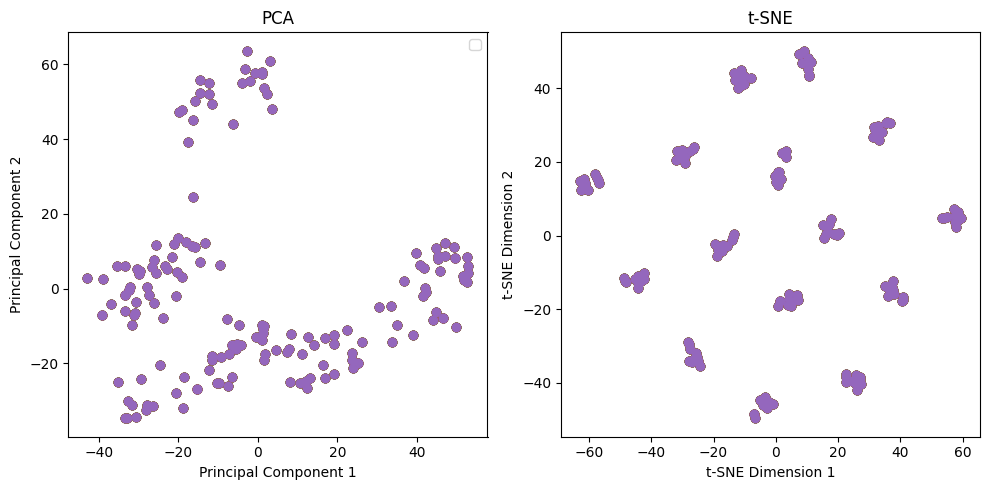

In [ ]:
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

XT = feat

# using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(XT)

# using t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(XT)

# Plotting PCA results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
for i in labels_true:
    plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.title('PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

# Plotting t-SNE results
plt.subplot(1, 2, 2)
for i in labels_true:
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1])

plt.title('t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()


## 4- Clustering



#### Distane Matrix

In [ ]:
from math import sqrt
dist = lambda p1, p2: sqrt(((p1-p2)**2).sum())
dist_matrix = np.asarray([[dist(p1, p2) for p2 in feat] for p1 in feat])

In [ ]:
df = pd.DataFrame(dist_matrix)
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,...,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,126.269144,118.973811,122.329201,121.890119,124.802114,125.597726,121.410929,126.079539,124.792904,118.642054,...,110.031411,106.589372,112.939142,107.785423,106.408987,109.843577,108.390627,106.971206,109.391739,110.946328
std,16.220681,16.145799,16.715826,15.768643,15.803840,18.896032,14.369486,18.709108,17.790720,16.574981,...,16.685896,17.119317,16.021878,18.124120,18.194139,16.547109,18.656648,18.484277,16.313981,15.428802
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,124.354827,115.806564,120.726580,119.031357,121.724133,124.500502,119.133722,125.093235,122.889766,114.453312,...,104.204173,102.778575,109.088348,102.459863,102.566666,105.091013,103.461950,101.835661,106.118269,106.632583
50%,130.390676,122.386535,127.000738,126.462526,128.683372,130.394436,124.734210,131.180316,128.498906,122.996522,...,112.115454,109.336096,115.262887,109.199927,108.436608,112.473382,109.790070,108.610525,109.983450,113.146985
75%,133.648150,128.270299,130.662913,129.348148,132.393427,135.260599,128.124627,135.029569,132.734963,127.740987,...,120.201653,115.344042,119.915449,117.626349,115.109620,118.379591,117.754064,116.998468,118.617541,118.422773
max,141.938883,139.335995,140.865392,138.905895,142.251936,145.878153,139.515862,143.986110,148.147091,139.160864,...,137.229037,132.672779,135.260599,134.451214,134.568944,133.245954,136.009830,134.140107,135.048725,136.661849


### 4-1 Mean shift

In [ ]:
from sklearn.cluster import estimate_bandwidth
bdw = estimate_bandwidth(feat, quantile=0.1)
bdw

96.37706594746534

In [ ]:
meanshift = MeanShift(bandwidth=65)
meanshift.fit(feat)

labels = meanshift.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.884       , Rand Index: 0.986


### 4-2 K-means

#### 4-2-1 Select k using silhouette score

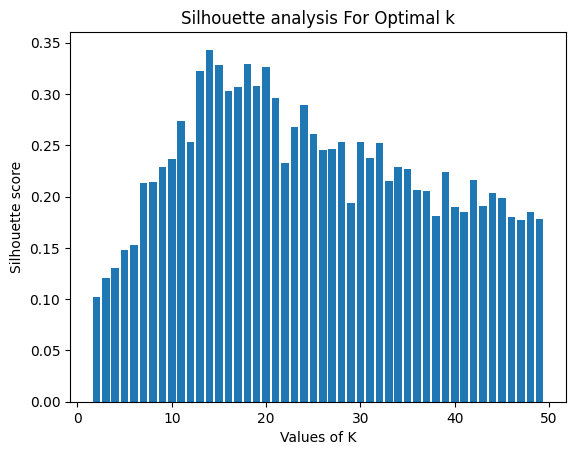

In [ ]:
from sklearn.metrics import silhouette_score

range_n_clusters = range(2,50)
silhouette_avg = []
for num_clusters in range_n_clusters:
 # initialise kmeans
 kmeans = KMeans(n_clusters=num_clusters, n_init="auto")
 kmeans.fit(feat)
 cluster_labels = kmeans.labels_
 # silhouette score
 silhouette_avg.append(silhouette_score(feat, cluster_labels))

# plt.plot(range_n_clusters,silhouette_avg,'bx-')
plt.bar(range_n_clusters, silhouette_avg)

plt.xlabel('Values of K')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis For Optimal k')
plt.show()

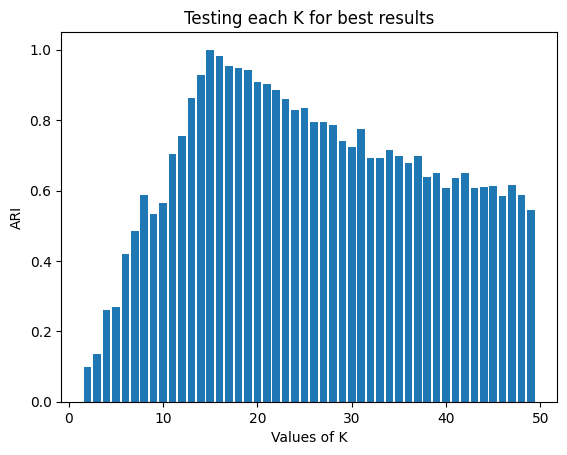

In [ ]:
range_n_clusters = range(2,50)

ARI_list = []
for num_clusters in range_n_clusters:
 # initialise kmeans
 kmeans = KMeans(n_clusters=num_clusters, n_init=10, init='k-means++')
 kmeans.fit(feat)
 cluster_labels = kmeans.labels_
 # silhouette score
 ARI_list.append(adjusted_rand_score(y_train, cluster_labels))

# plt.plot(range_n_clusters,silhouette_avg,'bx-')
plt.bar(range_n_clusters, ARI_list)

plt.xlabel('Values of K')
plt.ylabel('ARI')
plt.title('Testing each K for best results')
plt.show()

In [ ]:
kmeans_Sil = KMeans(n_clusters=15, init='k-means++', n_init=10, random_state=42)
kmeans_Sil.fit(feat)

labels = kmeans_Sil.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 1.000       , Rand Index: 1.000


#### 5-2-2 Select k using Elbow Method

/usr/local/lib/python3.10/dist-packages/yellowbrick/cluster/elbow.py:339: ConvergenceWarning: Number of distinct clusters (156) found smaller than n_clusters (157). Possibly due to duplicate points in X.
  self.estimator.fit(X, **kwargs)
/usr/local/lib/python3.10/dist-packages/yellowbrick/cluster/elbow.py:339: ConvergenceWarning: Number of distinct clusters (156) found smaller than n_clusters (158). Possibly due to duplicate points in X.
  self.estimator.fit(X, **kwargs)
/usr/local/lib/python3.10/dist-packages/yellowbrick/cluster/elbow.py:339: ConvergenceWarning: Number of distinct clusters (156) found smaller than n_clusters (159). Possibly due to duplicate points in X.
  self.estimator.fit(X, **kwargs)
/usr/local/lib/python3.10/dist-packages/yellowbrick/cluster/elbow.py:339: ConvergenceWarning: Number of distinct clusters (156) found smaller than n_clusters (160). Possibly due to duplicate points in X.
  self.estimator.fit(X, **kwargs)
/usr/local/lib/python3.10/dist-packages/yellowbr

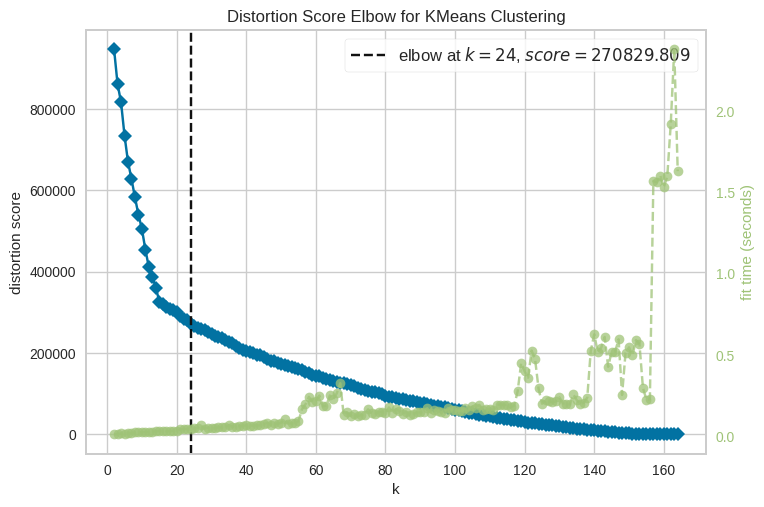

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model and visualizer
km = KMeans(random_state=42, init = "k-means++", n_init="auto")
visualizer = KElbowVisualizer(km, k=(2,165))

visualizer.fit(feat)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [ ]:
kmeans_ELM = KMeans(n_clusters=24, init='k-means++', n_init="auto", random_state=42)
kmeans_ELM.fit(feat)

labels = kmeans_ELM.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.843       , Rand Index: 0.984


### 4-3 Meanshift + Kmeans

In [ ]:
ms = MeanShift(bandwidth=68)
ms.fit(feat)

kmeans = KMeans(n_clusters=len(ms.cluster_centers_), init=ms.cluster_centers_, random_state=42)
kmeans.fit(feat)

labels = kmeans.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.907       , Rand Index: 0.989


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1362: RuntimeWarning: Explicit initial center position passed: performing only one init in KMeans instead of n_init=10.
  super()._check_params_vs_input(X, default_n_init=10)


### 4-4 DBSCAN

In [ ]:
from sklearn.neighbors import NearestNeighbors
from matplotlib import pyplot as plt

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(feat)
distances, indices = neighbors_fit.kneighbors(feat)

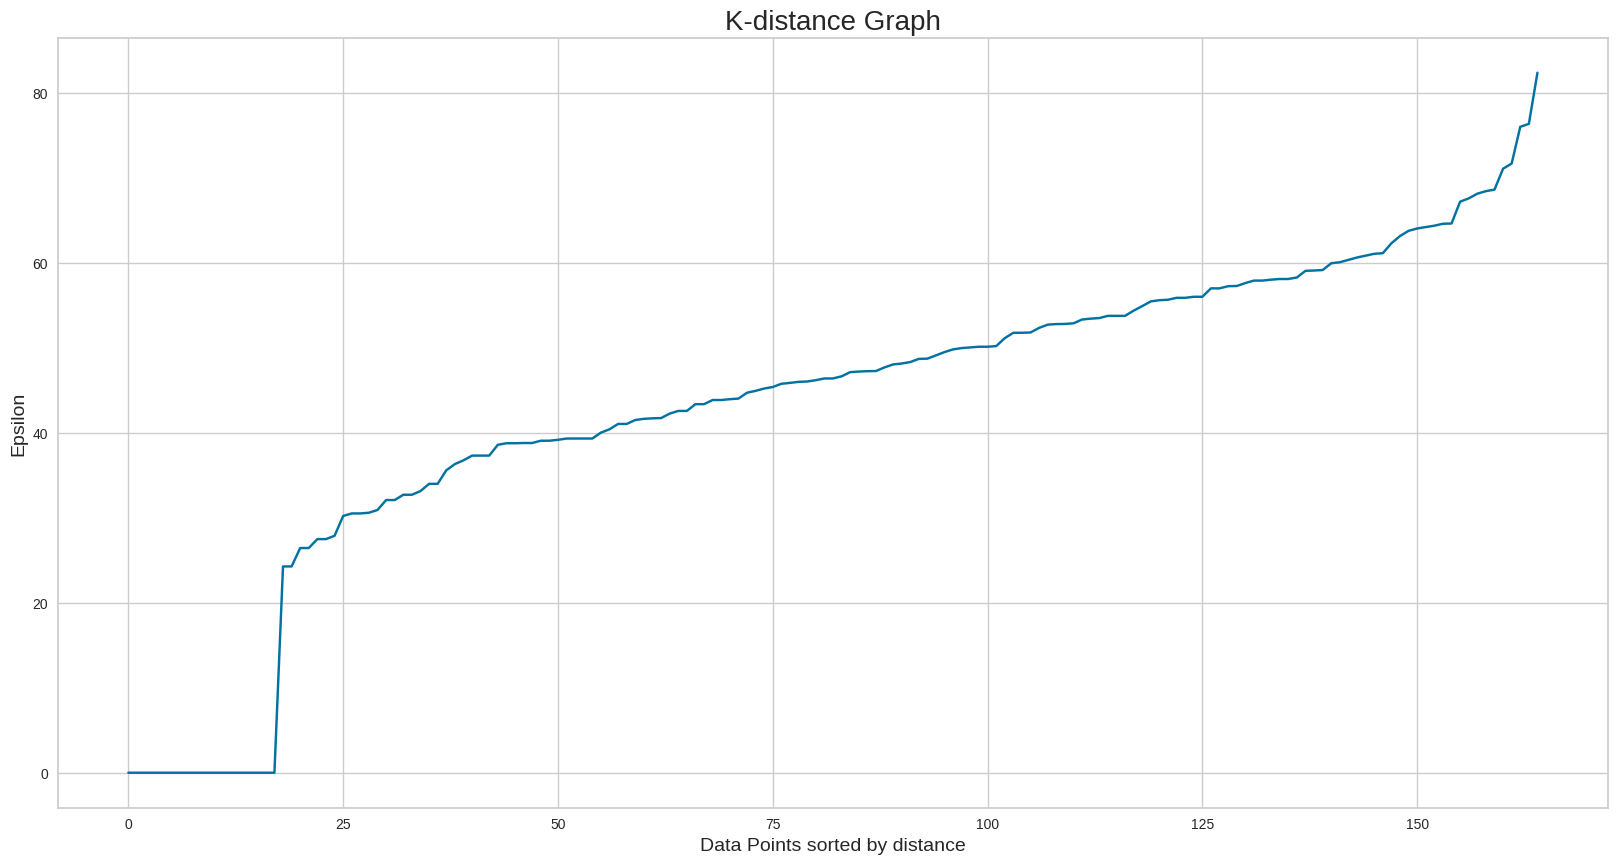

In [ ]:
distances = np.sort(distances, axis=0)
dist = distances[:,1]
plt.figure(figsize=(20,10))
plt.plot(dist)
plt.title('K-distance Graph',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

In [ ]:
dbc = DBSCAN(eps=60, min_samples=9)
dbc.fit(feat)

labels = dbc.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.032       , Rand Index: 0.280


In [ ]:
dbc = DBSCAN(eps=70, min_samples=3)
dbc.fit(feat)

labels = dbc.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.880       , Rand Index: 0.986


In [ ]:
dbc = DBSCAN(eps=77, min_samples=2)
dbc.fit(feat)

labels = dbc.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.927       , Rand Index: 0.991


### 4-5 Agglomerative

In [ ]:
agg = AgglomerativeClustering(n_clusters=17).fit(feat)

labels = agg.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.965       , Rand Index: 0.996


In [ ]:
agg = AgglomerativeClustering(n_clusters=15).fit(feat)

labels = agg.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 1.000       , Rand Index: 1.000


In [ ]:
agg = AgglomerativeClustering(n_clusters=17, linkage='complete').fit(feat)

labels = agg.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.966       , Rand Index: 0.996


In [ ]:
agg = AgglomerativeClustering(n_clusters=17, linkage='average').fit(feat)

labels = agg.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.904       , Rand Index: 0.989


In [ ]:
agg = AgglomerativeClustering(linkage='ward').fit(feat)

labels = agg.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.122       , Rand Index: 0.562


#### 4-5-1 Agglomerative using threshhold

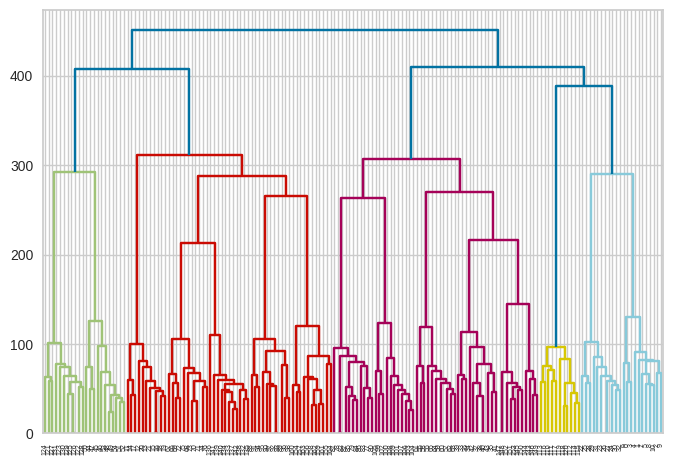

In [ ]:
from scipy.cluster.hierarchy import dendrogram

# instantiate Agglomerative Clustering instance
clustering_model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
# call fit method with array of sample coordinates passed as a parameter
trained_model = clustering_model.fit(feat)

# A method for generating dendrogram
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)
# plot dendrogram to visualize clusters
plot_dendrogram(trained_model)


In [ ]:
agg = AgglomerativeClustering(n_clusters=None,distance_threshold=100,compute_full_tree=True).fit(feat)

labels = agg.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 0.783       , Rand Index: 0.979


In [ ]:
agg = AgglomerativeClustering(n_clusters=None,distance_threshold=145,compute_full_tree=True).fit(feat)

labels = agg.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 1.000       , Rand Index: 1.000


In [ ]:
agg = AgglomerativeClustering(n_clusters=None,distance_threshold=210,compute_full_tree=True).fit(feat)

labels = agg.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 1.000       , Rand Index: 1.000


### 4-6 Best Algorithms

In [ ]:
clustering = KMeans(n_clusters=15, init='k-means++', n_init=10, random_state=42)
clustering.fit(feat)

labels = clustering.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 1.000       , Rand Index: 1.000


In [ ]:
clustering = AgglomerativeClustering(n_clusters=None,distance_threshold=145,compute_full_tree=True).fit(feat)

labels = clustering.labels_

print(f"Adjusted Rand Index: {adjusted_rand_score(y_train, labels):.3f} \
      , Rand Index: {rand_score(y_train, labels):.3f}")

Adjusted Rand Index: 1.000       , Rand Index: 1.000


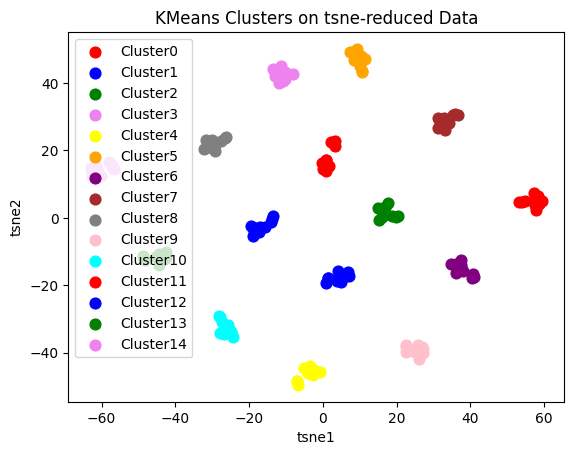

In [ ]:
X_tsne = tsne.fit_transform(feat)

pred_labels = clustering.labels_

colors = ['red', 'blue', 'green', 'violet', 'yellow', 'orange', 'purple', 'brown', 'gray', 'pink', 'cyan']  # Adjust colors as needed

unique_labels = np.unique(pred_labels)
for label in unique_labels:
  # Select data points belonging to the current cluster
  cluster_data = X_tsne[pred_labels == label]

  # Choose a color from the list based on the cluster number (modulo to handle more than 10 clusters)
  color = colors[label % len(colors)]

  # Create the scatter plot for the current cluster
  plt.scatter(cluster_data[:, 0], cluster_data[:, 1], s=60, c=color, label=f'Cluster{label}')

# Add labels and title
plt.xlabel('tsne1')
plt.ylabel('tsne2')  # Assuming the first two components from PCA are used
plt.title('KMeans Clusters on tsne-reduced Data')

# Add legend
plt.legend()

# Show the plot
plt.show()

In [ ]:
# holds the cluster id and the images { id: [images] }
groups = {}
for file, cluster in zip(y_train,clustering.labels_):
    if cluster not in groups.keys():
        groups[cluster] = []
        groups[cluster].append(file)
    else:
        groups[cluster].append(file)

# groups

## 5- Evaluation

### 5-1 Foldering

----------------------

Cluster 0:

----------------------


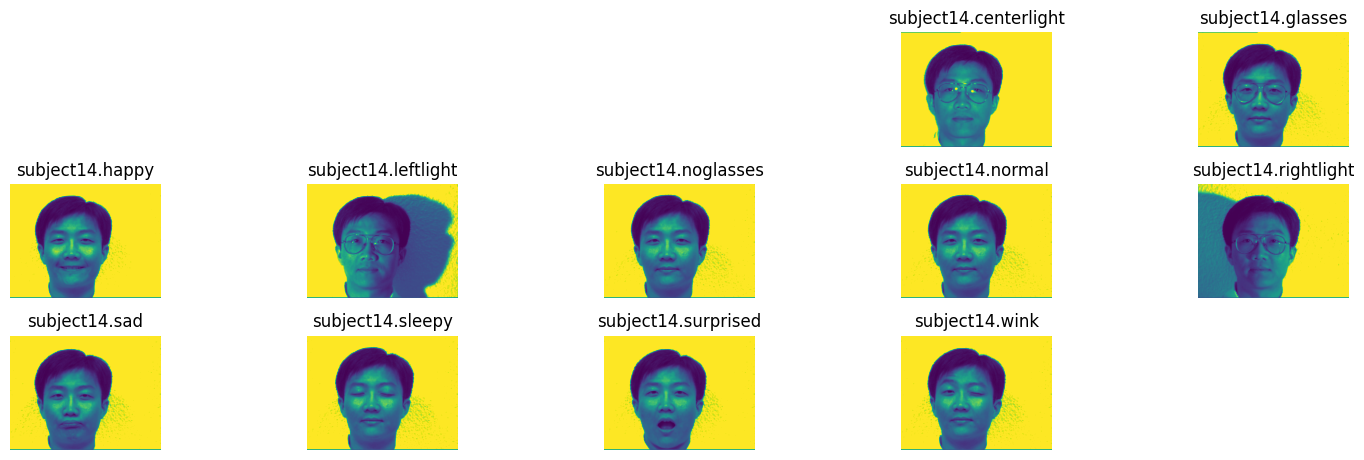

----------------------

Cluster 1:

----------------------


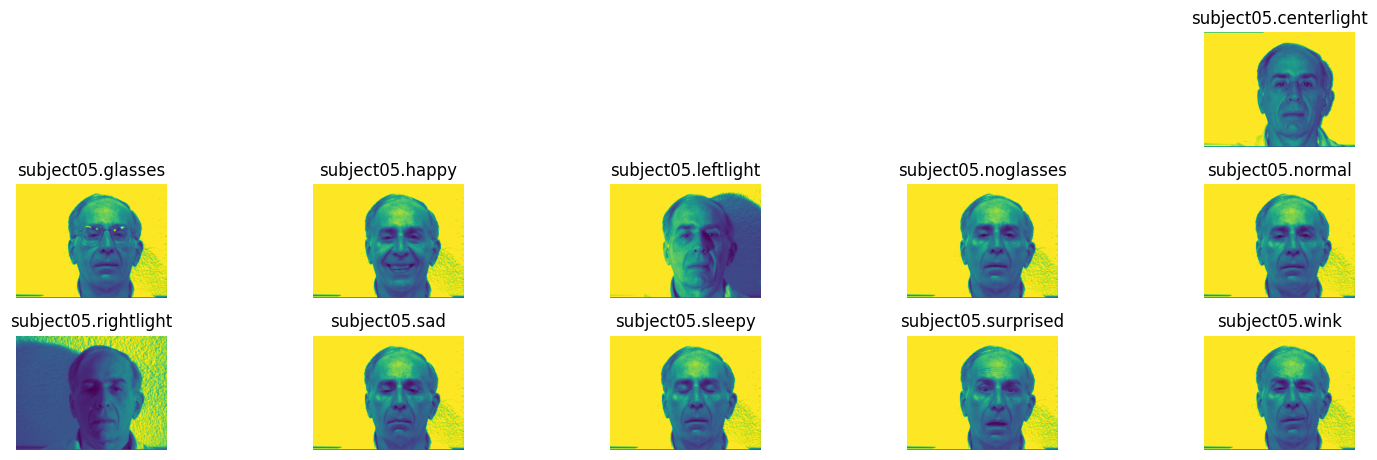

----------------------

Cluster 2:

----------------------


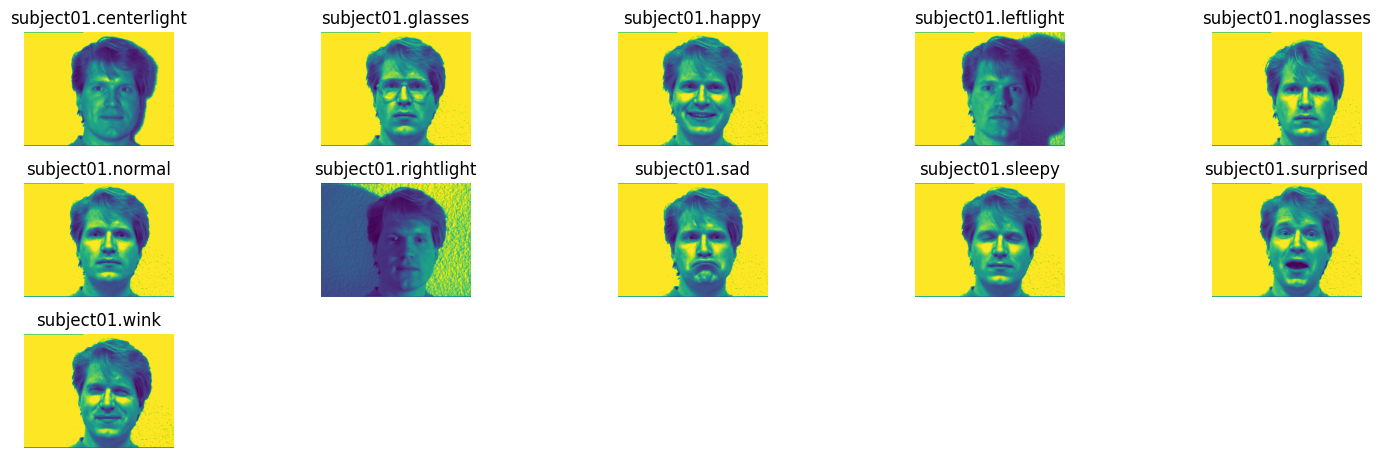

----------------------

Cluster 3:

----------------------


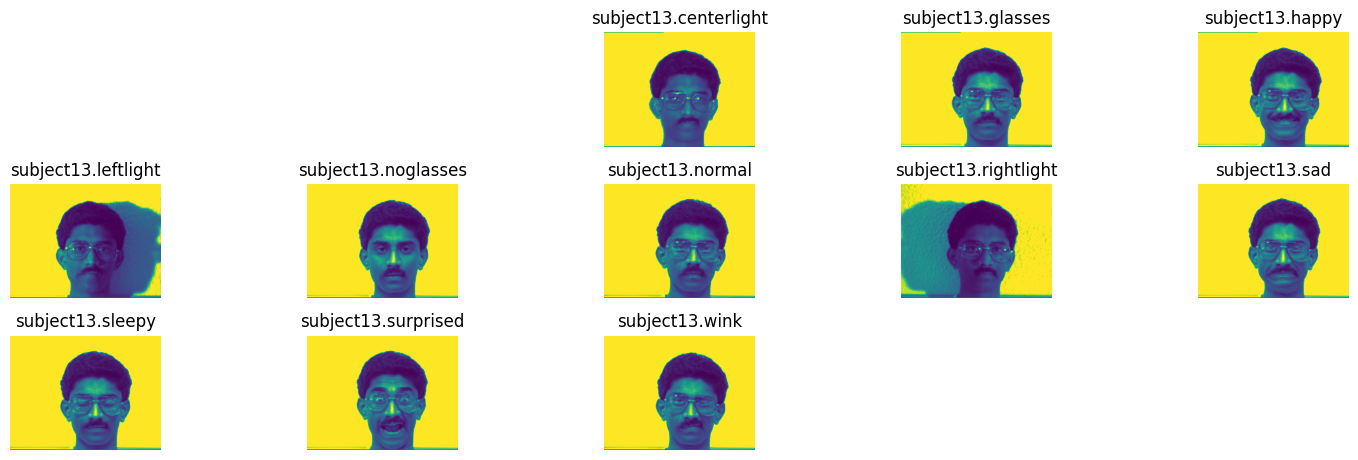

----------------------

Cluster 4:

----------------------


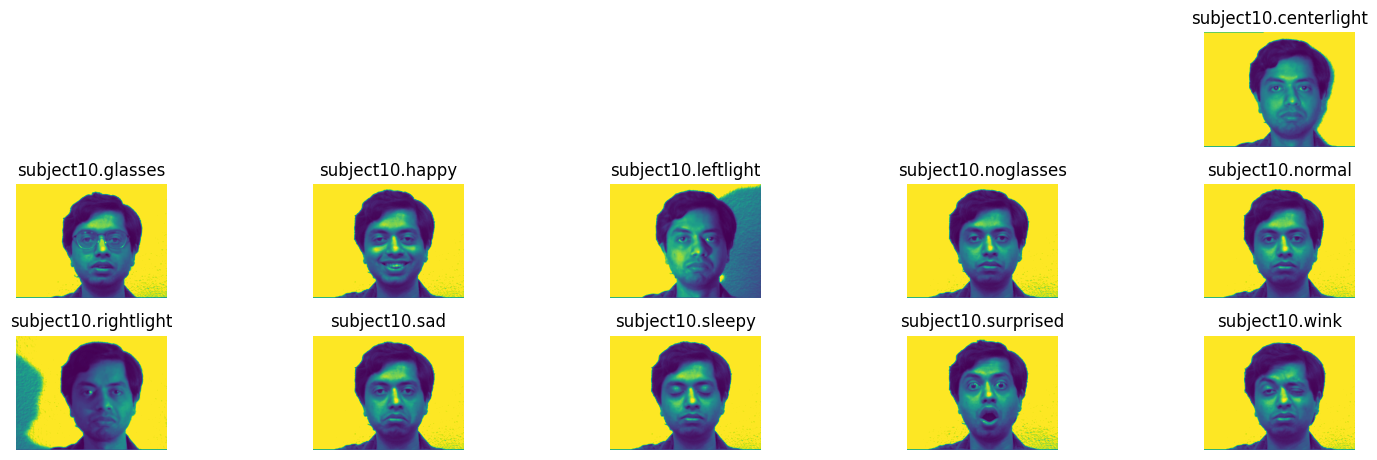

----------------------

Cluster 5:

----------------------


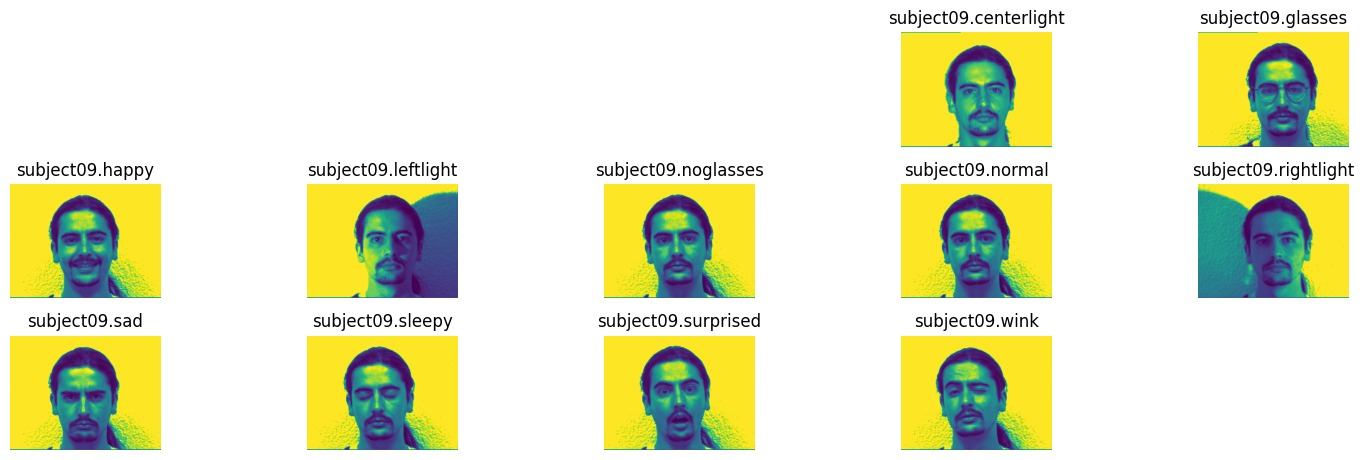

----------------------

Cluster 6:

----------------------


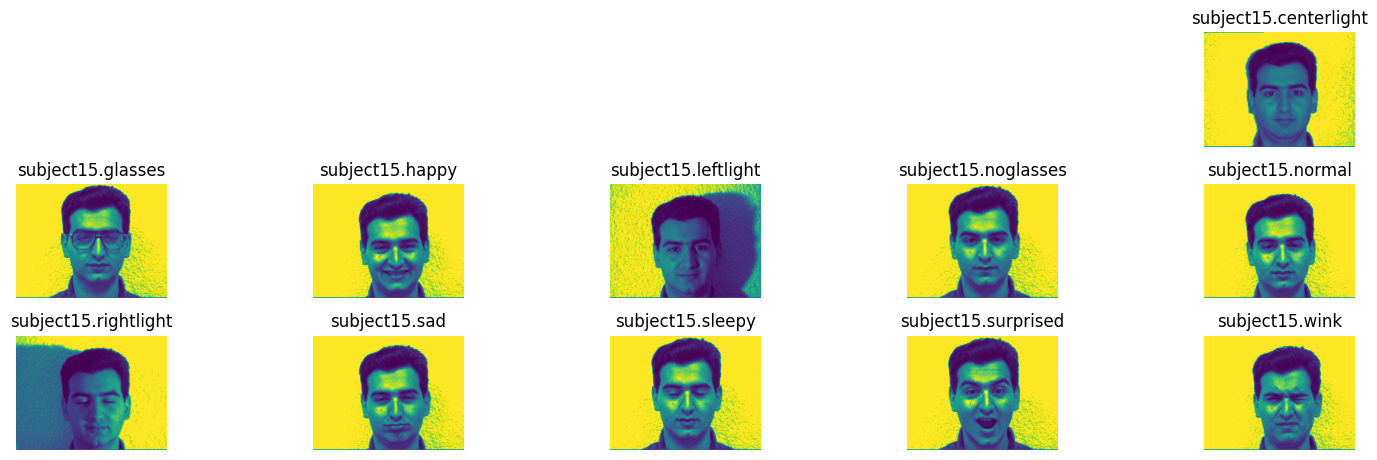

----------------------

Cluster 7:

----------------------


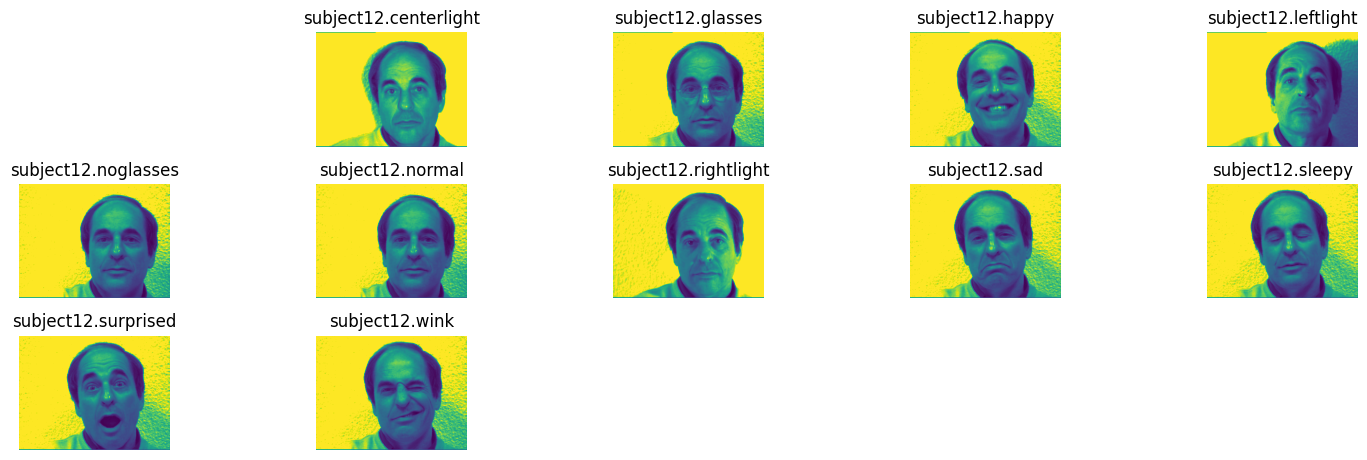

----------------------

Cluster 8:

----------------------


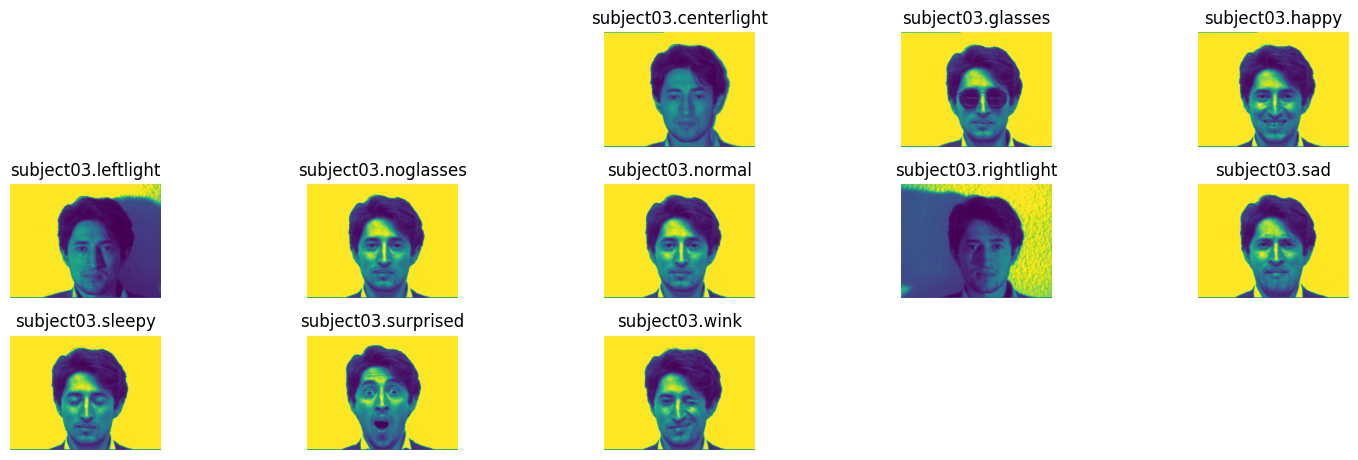

----------------------

Cluster 9:

----------------------


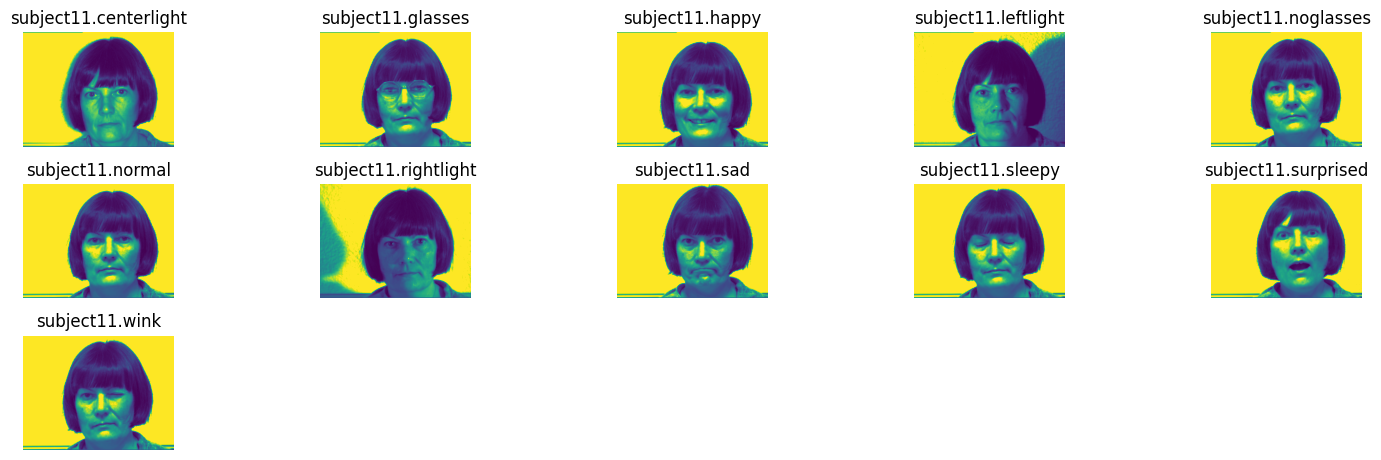

----------------------

Cluster 10:

----------------------


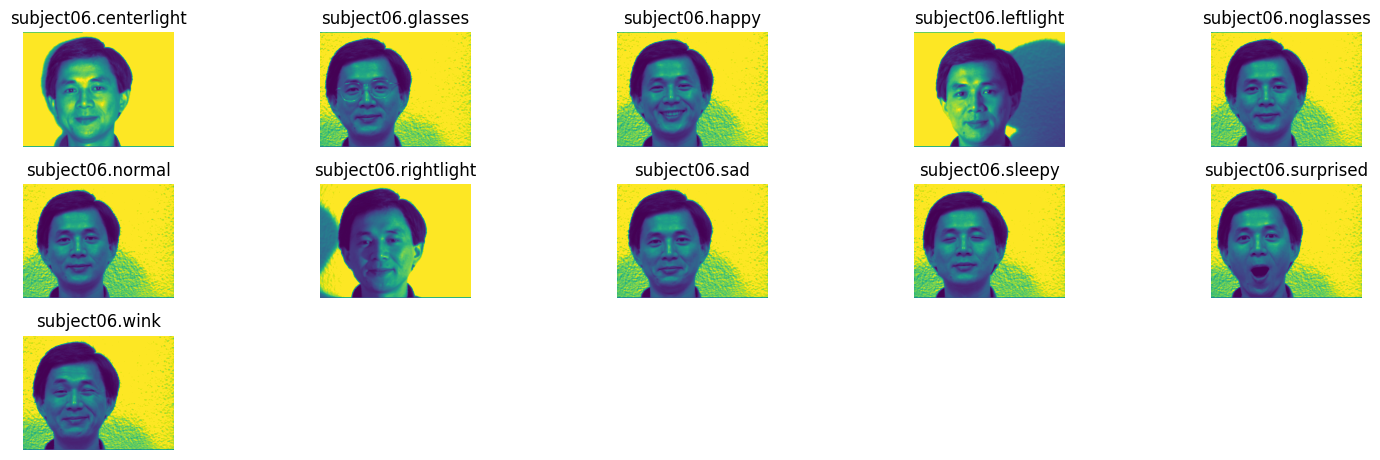

----------------------

Cluster 11:

----------------------


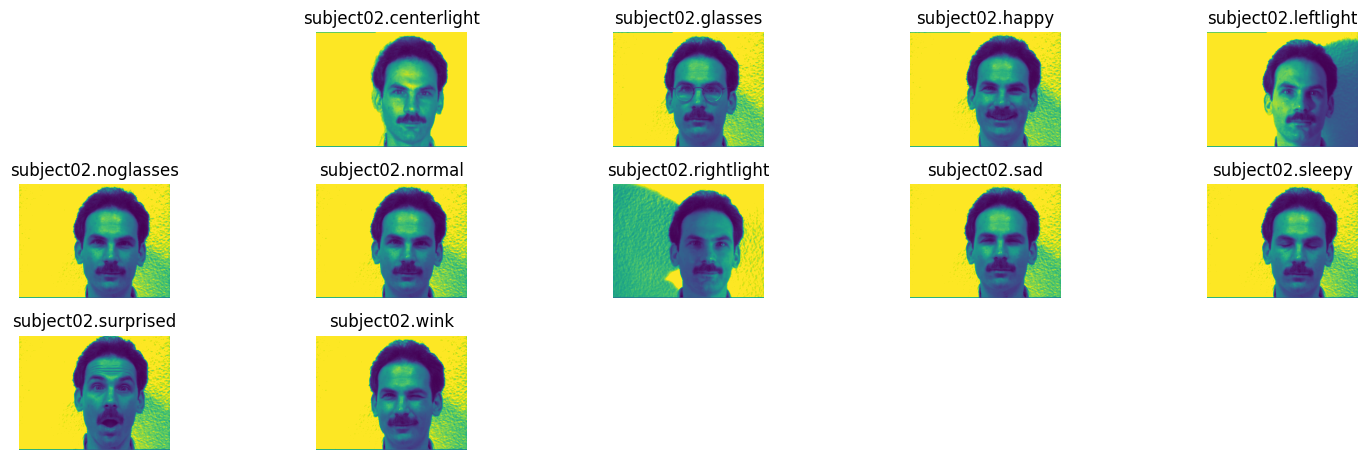

----------------------

Cluster 12:

----------------------


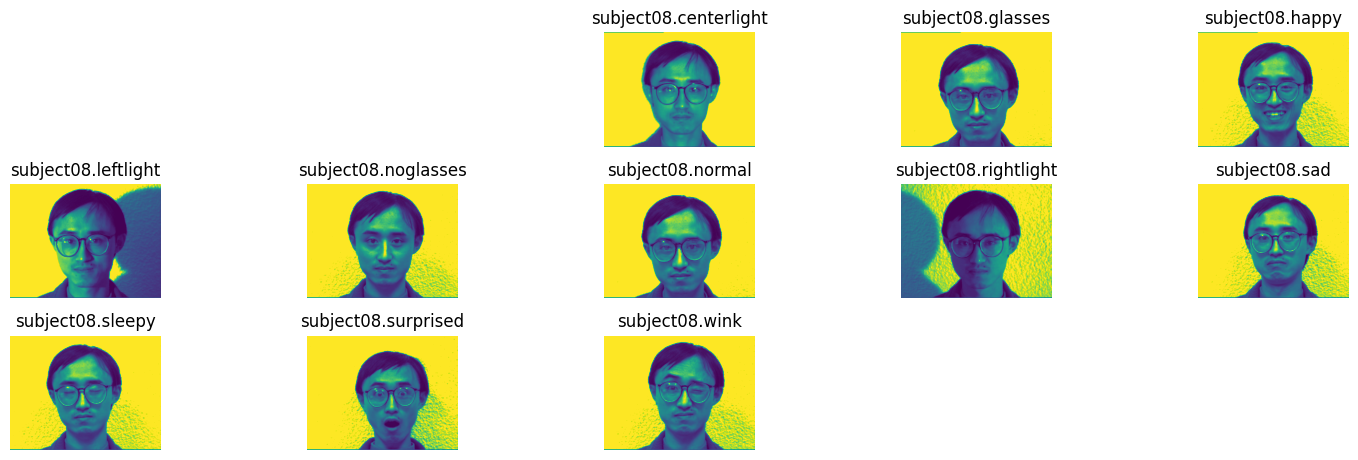

----------------------

Cluster 13:

----------------------


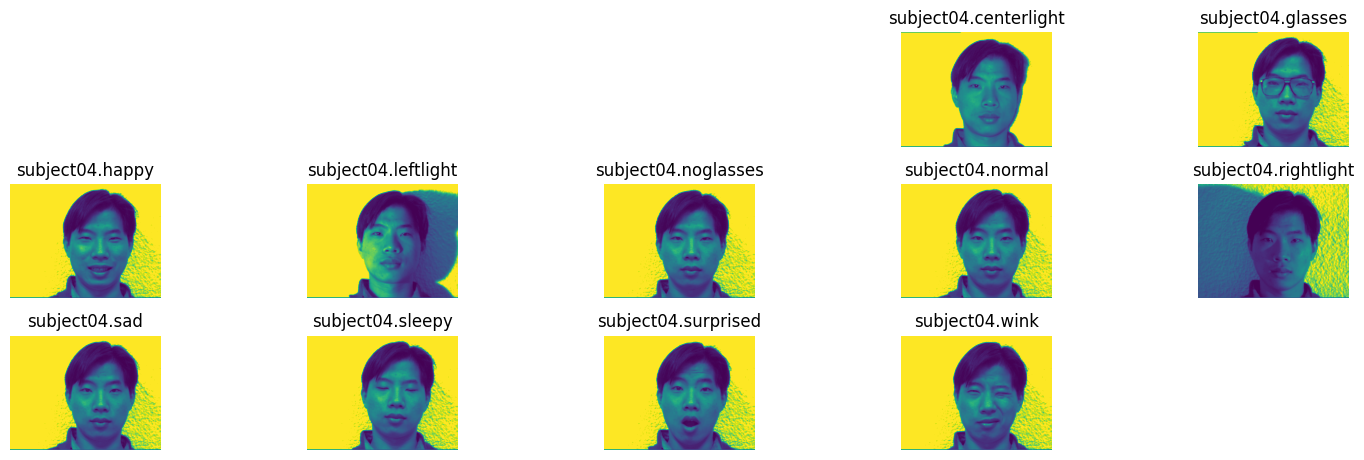

----------------------

Cluster 14:

----------------------


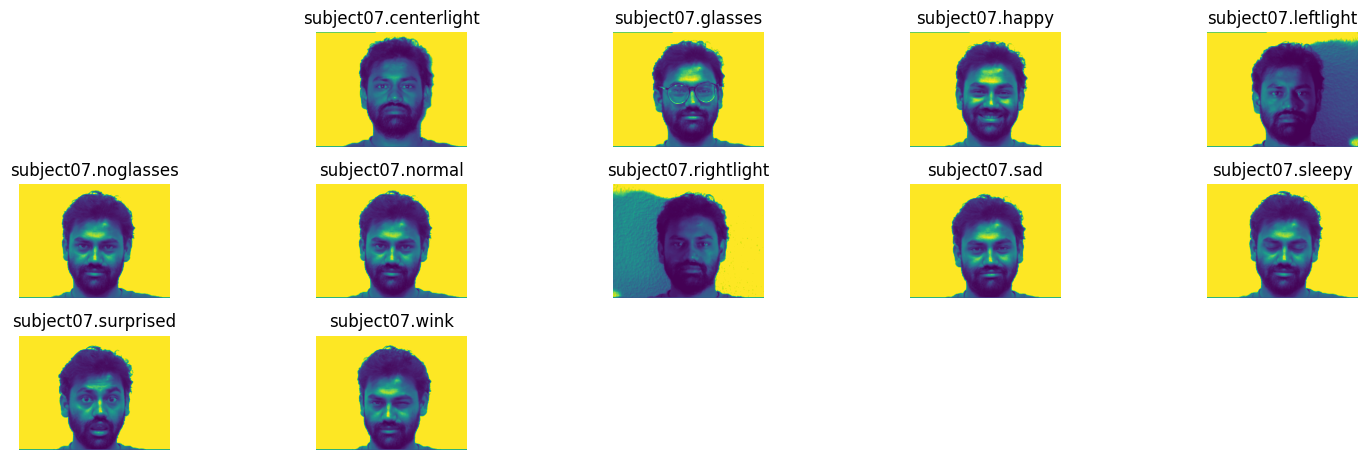

In [ ]:
import matplotlib.image as mpimg
import math

num_cols = 5
num_rows = math.ceil(len(pictures) / num_cols)


for j, label in enumerate(np.unique(clustering.labels_)):
  fig = plt.figure(figsize=(15,50))
  print(f"\nCluster {j}:\n")
  for i, im in enumerate(clustering.labels_):
    if im == label:
      img_path = pictures[i]
      img = mpimg.imread(img_path)

      title = os.path.basename(img_path)

      plt.subplot(num_rows, num_cols, i+1)
      plt.title(title)
      plt.imshow(img)
      plt.axis('off')

  plt.tight_layout()
  plt.show()

### 5-2 Rand Index

Definition

In [ ]:
from sklearn.metrics import rand_score
from scipy.special import comb
from itertools import combinations

def rand_index(true_labels, pred_labels):

    n = len(true_labels)
    tp, tn = 0, 0

    for (i, j) in combinations(range(n), 2):
        if true_labels[i] == true_labels[j] and pred_labels[i] == pred_labels[j]:
            tp += 1
        elif true_labels[i] != true_labels[j] and pred_labels[i] != pred_labels[j]:
            tn += 1


    rand_index = (tp + tn) / comb(n, 2)

    return rand_index

test

In [ ]:
print(f"Real Rand Index:    {rand_score(y_train, labels):.3f}\nCustom Rand Index:  {rand_index(y_train, labels):.3f}")

Real Rand Index:    1.000
Custom Rand Index:  1.000
